# 01 — Exploration et prétraitement du dataset Fashion-MNIST

**Projet : Optimisation multi-objectifs pour AutoML — Option 2**

Option 2 : Optimisation des hyperparamètres de modèles ML classiques.

Objectif : charger les données Fashion-MNIST, les préparer pour des modèles ML classiques (Random Forest, SVM, k-NN), visualiser la structure du dataset, et sauvegarder les splits Train/Validation/Test.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("Librairies chargées avec succès.")

Librairies chargées avec succès.


## 1. Chargement du dataset Fashion-MNIST

Fashion-MNIST contient 70 000 images de vêtements en noir et blanc, de taille 28×28 pixels répartis en 10 classes.
Pour les modèles ML classiques, les images sont aplaties en vecteurs de 784 features.

In [2]:
# Chargement via keras si disponible, sinon via les fichiers .npy préparés
try:
    from tensorflow.keras.datasets import fashion_mnist
    (X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = fashion_mnist.load_data()
    print("Dataset chargé via Keras.")
except ImportError:
    # Reconstruction depuis les fichiers .npy préparés (déjà normalisés et reshapés pour CNN)
    print("TensorFlow non disponible, chargement depuis les fichiers .npy...")
    X_train_cnn = np.load("data_prepared/X_train_final.npy")  # (48000, 28, 28, 1)
    X_val_cnn   = np.load("data_prepared/X_val.npy")           # (12000, 28, 28, 1)
    X_test_cnn  = np.load("data_prepared/X_test_cnn.npy")      # (10000, 28, 28, 1)
    y_train_raw = np.argmax(np.load("data_prepared/y_train_final.npy"), axis=1)
    y_val_raw   = np.argmax(np.load("data_prepared/y_val.npy"), axis=1)
    y_test_raw  = np.load("data_prepared/y_test.npy")
    # Aplatir : (N, 28, 28, 1) -> (N, 784)
    X_train_flat = X_train_cnn.reshape(len(X_train_cnn), -1)
    X_val_flat   = X_val_cnn.reshape(len(X_val_cnn), -1)
    X_test_flat  = X_test_cnn.reshape(len(X_test_cnn), -1)
    print(f"X_train_flat: {X_train_flat.shape}")
    print(f"X_val_flat  : {X_val_flat.shape}")
    print(f"X_test_flat : {X_test_flat.shape}")

class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]
print("\n10 classes :", class_names)

TensorFlow non disponible, chargement depuis les fichiers .npy...
X_train_flat: (48000, 784)
X_val_flat  : (12000, 784)
X_test_flat : (10000, 784)

10 classes : ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


## 2. Préparation complète des données (si chargement via Keras)

In [3]:
try:
    X_train_raw  # Vérifie si on a chargé via Keras

    # Normalisation : pixels de [0,255] -> [0,1]
    X_train_norm = X_train_raw.astype("float32") / 255.0
    X_test_norm  = X_test_raw.astype("float32") / 255.0

    # Aplatissement : (N, 28, 28) -> (N, 784) pour les modèles ML classiques
    X_train_flat_all = X_train_norm.reshape(len(X_train_norm), -1)
    X_test_flat      = X_test_norm.reshape(len(X_test_norm), -1)

    print(f"Pixels normalisés : min={X_train_flat_all.min():.2f}, max={X_train_flat_all.max():.2f}")

    # Split Train/Validation stratifié
    X_train_flat, X_val_flat, y_train_raw_split, y_val_raw = train_test_split(
        X_train_flat_all, y_train_raw,
        test_size=0.2, random_state=42, stratify=y_train_raw
    )
    y_train_raw_final = y_train_raw_split

    print(f"X_train_flat : {X_train_flat.shape}")
    print(f"X_val_flat   : {X_val_flat.shape}")
    print(f"X_test_flat  : {X_test_flat.shape}")

except NameError:
    # Déjà chargé depuis .npy
    y_train_raw_final = y_train_raw
    print("Données déjà préparées depuis les fichiers .npy.")

Données déjà préparées depuis les fichiers .npy.


## 3. Visualisation des images

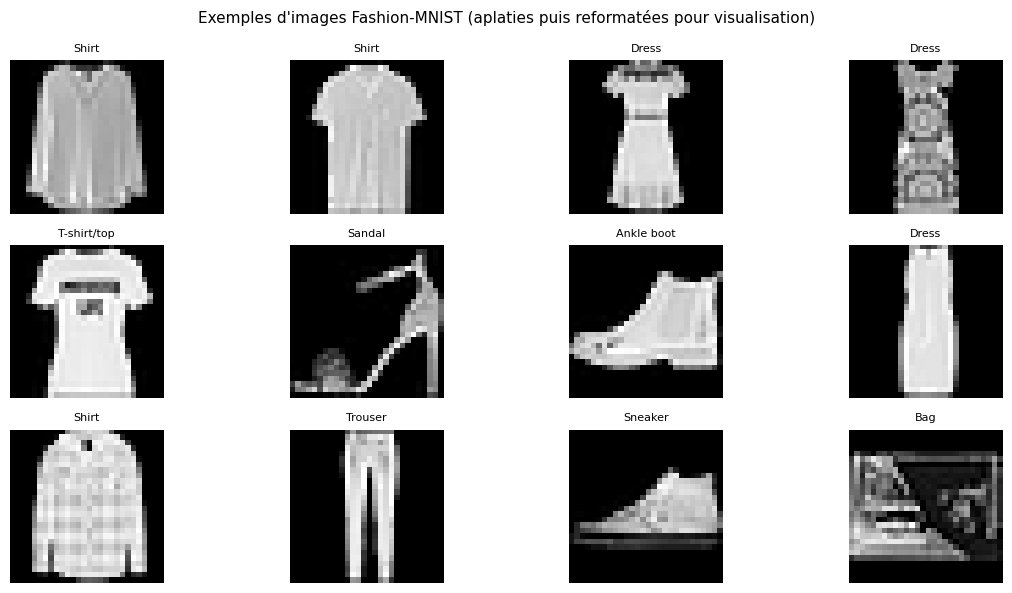

In [4]:
# Afficher quelques images du dataset
plt.figure(figsize=(12, 6))
for i in range(12):
    plt.subplot(3, 4, i + 1)
    img = X_train_flat[i].reshape(28, 28)
    plt.imshow(img, cmap="gray")
    plt.title(class_names[y_train_raw_final[i]], fontsize=8)
    plt.axis("off")
plt.suptitle("Exemples d'images Fashion-MNIST (aplaties puis reformatées pour visualisation)", fontsize=11)
plt.tight_layout()
plt.show()

## 4. Distribution des classes

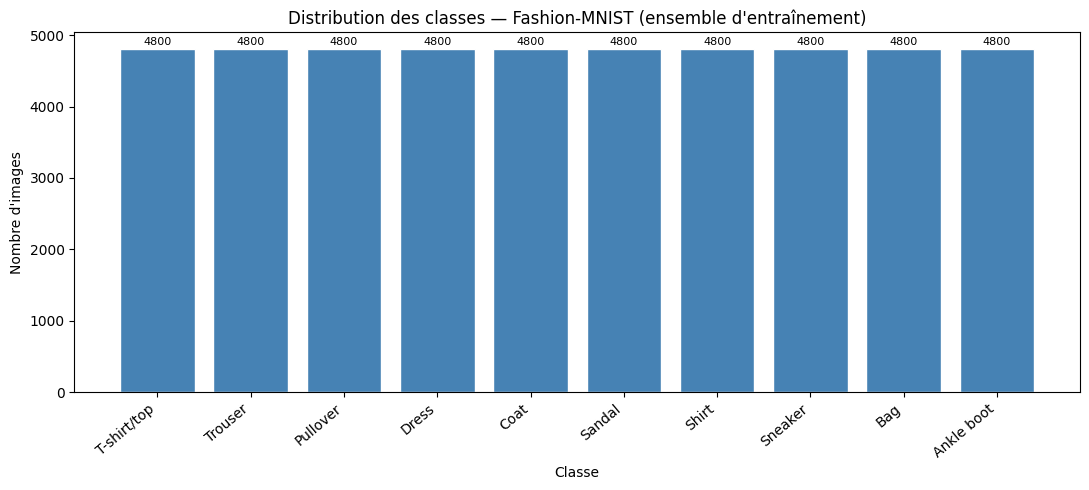

     classe  nombre_images  proportion
T-shirt/top           4800        10.0
    Trouser           4800        10.0
   Pullover           4800        10.0
      Dress           4800        10.0
       Coat           4800        10.0
     Sandal           4800        10.0
      Shirt           4800        10.0
    Sneaker           4800        10.0
        Bag           4800        10.0
 Ankle boot           4800        10.0

Les classes sont PARFAITEMENT équilibrées : pas besoin de F1-score pondéré.


In [5]:
counts = pd.Series(y_train_raw_final).value_counts().sort_index()
labels = [class_names[i] for i in counts.index]

plt.figure(figsize=(11, 5))
bars = plt.bar(labels, counts.values, color="steelblue", edgecolor="white")
plt.xticks(rotation=40, ha="right")
plt.title("Distribution des classes — Fashion-MNIST (ensemble d'entraînement)")
plt.xlabel("Classe")
plt.ylabel("Nombre d'images")
for bar, count in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30, str(count),
             ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

df_dist = pd.DataFrame({"classe": labels, "nombre_images": counts.values, "proportion": (counts.values / counts.values.sum() * 100).round(1)})
print(df_dist.to_string(index=False))
print("\nLes classes sont PARFAITEMENT équilibrées : pas besoin de F1-score pondéré.")

## 5. Adaptation pour les modèles ML classiques

Contrairement aux CNN qui travaillent sur les images 2D, les modèles ML classiques (Random Forest, SVM, k-NN) nécessitent des **vecteurs 1D** de features.

Chaque image 28×28 est aplatie en un vecteur de **784 features** (valeur de chaque pixel normalisée entre 0 et 1).

In [6]:
print("=== Résumé des données pour les modèles ML classiques ===")
print(f"X_train_flat : {X_train_flat.shape}  -> {X_train_flat.shape[0]} images, {X_train_flat.shape[1]} features (28x28 pixels aplatis)")
print(f"X_val_flat   : {X_val_flat.shape}")
print(f"X_test_flat  : {X_test_flat.shape}")
print(f"\nValeurs pixel : min={X_train_flat.min():.4f}, max={X_train_flat.max():.4f}")
print(f"Mémoire X_train : {X_train_flat.nbytes / 1e6:.1f} MB")
print(f"\nClasses y_train (entiers 0-9) : {np.unique(y_train_raw_final)}")

=== Résumé des données pour les modèles ML classiques ===
X_train_flat : (48000, 784)  -> 48000 images, 784 features (28x28 pixels aplatis)
X_val_flat   : (12000, 784)
X_test_flat  : (10000, 784)

Valeurs pixel : min=0.0000, max=1.0000
Mémoire X_train : 150.5 MB

Classes y_train (entiers 0-9) : [0 1 2 3 4 5 6 7 8 9]


## 6. Sous-ensemble pour optimisation rapide

L'entraînement de SVM et k-NN sur 48 000 images est très lent. On crée un sous-ensemble de 10 000 images pour les trials d'optimisation, et on conserve le full dataset pour l'évaluation finale.

In [7]:
N_OPTIM = 10000  # Taille du sous-ensemble pour l'optimisation

idx = np.random.RandomState(42).choice(len(X_train_flat), N_OPTIM, replace=False)
X_train_optim = X_train_flat[idx]
y_train_optim = y_train_raw_final[idx]

print(f"Sous-ensemble d'optimisation : {X_train_optim.shape} ({N_OPTIM} images)")
print(f"Distribution des classes dans le sous-ensemble :")
unique, counts_sub = np.unique(y_train_optim, return_counts=True)
for u, c in zip(unique, counts_sub):
    print(f"  {class_names[u]:15s}: {c}")

Sous-ensemble d'optimisation : (10000, 784) (10000 images)
Distribution des classes dans le sous-ensemble :
  T-shirt/top    : 1007
  Trouser        : 1036
  Pullover       : 982
  Dress          : 987
  Coat           : 1001
  Sandal         : 986
  Shirt          : 1035
  Sneaker        : 977
  Bag            : 1021
  Ankle boot     : 968


## 7. Sauvegarde des données préparées

In [8]:
os.makedirs("data_prepared", exist_ok=True)

np.save("data_prepared/X_train_flat.npy", X_train_flat)
np.save("data_prepared/X_val_flat.npy", X_val_flat)
np.save("data_prepared/X_test_flat.npy", X_test_flat)
np.save("data_prepared/y_train_flat.npy", y_train_raw_final)
np.save("data_prepared/y_val_flat.npy", y_val_raw)
np.save("data_prepared/y_test_flat.npy", y_test_raw)

# Sous-ensembles pour l'optimisation
np.save("data_prepared/X_train_optim.npy", X_train_optim)
np.save("data_prepared/y_train_optim.npy", y_train_optim)

print("Données sauvegardées :")
for f in os.listdir("data_prepared"):
    size = os.path.getsize(f"data_prepared/{f}") / 1e6
    print(f"  {f:35s} {size:.1f} MB")

Données sauvegardées :
  X_test_cnn.npy                      31.4 MB
  X_test_flat.npy                     31.4 MB
  X_train_final.npy                   150.5 MB
  X_train_flat.npy                    150.5 MB
  X_train_optim.npy                   31.4 MB
  X_val.npy                           37.6 MB
  X_val_flat.npy                      37.6 MB
  y_test.npy                          0.0 MB
  y_test_cat.npy                      0.8 MB
  y_test_flat.npy                     0.0 MB
  y_train_final.npy                   3.8 MB
  y_train_flat.npy                    0.4 MB
  y_train_optim.npy                   0.1 MB
  y_val.npy                           1.0 MB
  y_val_flat.npy                      0.1 MB


## 8. Récapitulatif — Espace de recherche défini

| Modèle | Hyperparamètres optimisés | Objectifs |
|--------|--------------------------|----------|
| **Random Forest** | n_estimators, max_depth, min_samples_split, max_features | Accuracy ↑, Temps inférence ↓ |
| **SVM** | C, kernel, gamma | Accuracy ↑, Temps entraînement ↓ |
| **k-NN** | n_neighbors, weights, metric | Accuracy ↑, Temps inférence ↓ |

**Algorithmes d'optimisation à comparer :**
- NSGA-II (via pymoo)
- Bayesian Optimization (via Optuna)
- Hyperband (via Optuna avec HyperbandSampler)
- Genetic Algorithm (via pymoo ou implémentation dédiée)